In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.tree import plot_tree

In [30]:
df= pd.read_csv("Dataset/CVD_Dataset.csv")
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


In [31]:
df.isna().sum().sum()

np.int64(1022)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   str    
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   str    
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   str    
 11  Diabetes Status               1529 non-null   str    
 12  Physical Activity Level       1529 non-null   str    
 13  Family History

Llenar los valores nulos con el promedio

In [33]:
# Primero sacamos solo las columnas con valores numericos como float y int
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
# Despues con la función fillna rellenamos los valores faltantes con la media de cada columna
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].mean())

In [34]:
print(df.isnull().sum())

Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Blood Pressure (mmHg)           0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Height (cm)                     0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Blood Pressure Category         0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
CVD Risk Level                  0
dtype: int64


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   str    
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1529 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   str    
 7   Total Cholesterol (mg/dL)     1529 non-null   float64
 8   HDL (mg/dL)                   1529 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 10  Smoking Status                1529 non-null   str    
 11  Diabetes Status               1529 non-null   str    
 12  Physical Activity Level       1529 non-null   str    
 13  Family History

In [36]:
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1529.00000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,47.02550,85.917427,1.754111,28.465997,91.773214,198.539148,56.197378,117.485636,175.390600,0.525727,125.627572,82.917761,111.550685,16.960925
std,12.09988,20.448054,0.110583,6.889701,12.539276,56.396652,15.640504,29.617668,10.975694,0.079086,21.592259,14.330550,57.521754,2.379735
min,25.00000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,-18.000000,10.530000
25%,37.00000,67.970000,1.670000,22.811000,80.900000,151.000000,43.000000,93.000000,167.000000,0.463000,108.000000,71.000000,63.000000,15.290000
50%,47.00000,85.917427,1.754111,28.465997,91.773214,198.539148,56.197378,117.485636,175.390600,0.525727,125.627572,82.917761,111.550685,16.960925
75%,55.00000,104.100000,1.840000,33.700000,101.800000,247.000000,69.000000,138.000000,184.000000,0.581000,140.000000,93.000000,157.000000,18.510000
max,79.00000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


In [37]:
print(df.Sex.unique())
print(df['Smoking Status'].unique())
print(df['Diabetes Status'].unique())
print(df['Physical Activity Level'].unique())
print(df['Family History of CVD'].unique())
print(df['CVD Risk Level'].unique())
print(df['Blood Pressure Category'].unique())

<StringArray>
['F', 'M']
Length: 2, dtype: str
<StringArray>
['N', 'Y']
Length: 2, dtype: str
<StringArray>
['Y', 'N']
Length: 2, dtype: str
<StringArray>
['Low', 'High', 'Moderate']
Length: 3, dtype: str
<StringArray>
['N', 'Y']
Length: 2, dtype: str
<StringArray>
['INTERMEDIARY', 'HIGH', 'LOW']
Length: 3, dtype: str
<StringArray>
['Elevated', 'Hypertension Stage 1', 'Normal', 'Hypertension Stage 2']
Length: 4, dtype: str


In [38]:
# cambiar el tipo de datos
df['Sex'] = df['Sex'].replace({'M': 0, 'F': 1})
df['Smoking Status'] = df['Smoking Status'].replace({'N': 0, 'Y': 1})
df['Diabetes Status'] = df['Diabetes Status'].replace({'N': 0, 'Y': 1})
df['Physical Activity Level'] = df['Physical Activity Level'].replace({'Low': 0, 'Moderate': 1, 'High': 2})
df['Family History of CVD'] = df['Family History of CVD'].replace({'N': 0, 'Y': 1})
df['CVD Risk Level'] = df['CVD Risk Level'].replace({'LOW': 0, 'INTERMEDIARY': 1, 'HIGH': 2})
df['Blood Pressure Category'] = df['Blood Pressure Category'].replace({'Normal': 0, 'Elevated': 1, 'Hypertension Stage 1': 2, 'Hypertension Stage 2': 3, 'Hypertensive Crisis': 4})

df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,1,32.0000,69.100000,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,0,0,171.0000,0.504,125.0,79.0,1,140.0,17.93,1
1,1,55.0000,118.700000,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,2,1,169.0000,0.488,139.0,70.0,2,82.0,20.51,2
2,0,47.0255,85.917427,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,2,1,183.0000,0.583,104.0,77.0,0,0.0,12.64,1
3,0,44.0000,108.300000,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,2,1,175.3906,0.537,140.0,83.0,2,58.0,16.36,1
4,1,32.0000,99.500000,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,2,0,186.0000,0.552,144.0,83.0,2,52.0,17.88,1


In [39]:
# Definimos el diccionario de traducción
columnas_español = {
    'Sex': 'Sexo',
    'Age': 'Edad',
    'Weight (kg)': 'Peso(kg)',
    'Height (m)': 'Altura(m)',
    'BMI': 'IMC',
    'Abdominal Circumference (cm)': 'Circunferencia_Abdominal(cm)',
    'Blood Pressure (mmHg)': 'Presion_Arterial(mmHg)',
    'Total Cholesterol (mg/dL)': 'Colesterol_Total(mg/dL)',
    'HDL (mg/dL)': 'Colesterol_HDL(mg/dL)',
    'Fasting Blood Sugar (mg/dL)': 'Glucosa_Ayunas(mg/dL)',
    'Smoking Status': 'Estado_Tabaquismo',
    'Diabetes Status': 'Estado_Diabetes',
    'Physical Activity Level': 'Nivel_Actividad_Fisica',
    'Family History of CVD': 'Antecedentes_Familiares_ECV',
    'Height (cm)': 'Altura(cm)',
    'Waist-to-Height Ratio': 'Relacion_Cintura_Altura',
    'Systolic BP': 'Presion_Sistolica',
    'Diastolic BP': 'Presion_Diastolica',
    'Blood Pressure Category': 'Categoria_Presion_Arterial',
    'Estimated LDL (mg/dL)': 'LDL_Estimado(mg/dL)',
    'CVD Risk Score': 'Puntaje_Riesgo_ECV',
    'CVD Risk Level': 'Nivel_Riesgo_ECV'
}

# Aplicamos el cambio
df = df.rename(columns=columnas_español)
# Verificamos los nuevos nombres
print(df.columns)

Index(['Sexo', 'Edad', 'Peso(kg)', 'Altura(m)', 'IMC',
       'Circunferencia_Abdominal(cm)', 'Presion_Arterial(mmHg)',
       'Colesterol_Total(mg/dL)', 'Colesterol_HDL(mg/dL)',
       'Glucosa_Ayunas(mg/dL)', 'Estado_Tabaquismo', 'Estado_Diabetes',
       'Nivel_Actividad_Fisica', 'Antecedentes_Familiares_ECV', 'Altura(cm)',
       'Relacion_Cintura_Altura', 'Presion_Sistolica', 'Presion_Diastolica',
       'Categoria_Presion_Arterial', 'LDL_Estimado(mg/dL)',
       'Puntaje_Riesgo_ECV', 'Nivel_Riesgo_ECV'],
      dtype='str')


In [40]:
df.columns

Index(['Sexo', 'Edad', 'Peso(kg)', 'Altura(m)', 'IMC',
       'Circunferencia_Abdominal(cm)', 'Presion_Arterial(mmHg)',
       'Colesterol_Total(mg/dL)', 'Colesterol_HDL(mg/dL)',
       'Glucosa_Ayunas(mg/dL)', 'Estado_Tabaquismo', 'Estado_Diabetes',
       'Nivel_Actividad_Fisica', 'Antecedentes_Familiares_ECV', 'Altura(cm)',
       'Relacion_Cintura_Altura', 'Presion_Sistolica', 'Presion_Diastolica',
       'Categoria_Presion_Arterial', 'LDL_Estimado(mg/dL)',
       'Puntaje_Riesgo_ECV', 'Nivel_Riesgo_ECV'],
      dtype='str')

In [41]:
df.head()

,Sexo,Edad,Peso(kg),Altura(m),IMC,Circunferencia_Abdominal(cm),Presion_Arterial(mmHg),Colesterol_Total(mg/dL),Colesterol_HDL(mg/dL),Glucosa_Ayunas(mg/dL),...,Nivel_Actividad_Fisica,Antecedentes_Familiares_ECV,Altura(cm),Relacion_Cintura_Altura,Presion_Sistolica,Presion_Diastolica,Categoria_Presion_Arterial,LDL_Estimado(mg/dL),Puntaje_Riesgo_ECV,Nivel_Riesgo_ECV
0,1,32.0000,69.100000,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,0,0,171.0000,0.504,125.0,79.0,1,140.0,17.93,1
1,1,55.0000,118.700000,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,2,1,169.0000,0.488,139.0,70.0,2,82.0,20.51,2
2,0,47.0255,85.917427,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,2,1,183.0000,0.583,104.0,77.0,0,0.0,12.64,1
3,0,44.0000,108.300000,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,2,1,175.3906,0.537,140.0,83.0,2,58.0,16.36,1
4,1,32.0000,99.500000,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,2,0,186.0000,0.552,144.0,83.0,2,52.0,17.88,1


In [78]:
df.drop(columns=['Puntaje_Riesgo_ECV','Presion_Arterial(mmHg)'])

,Sexo,Edad,Peso(kg),Altura(m),IMC,Circunferencia_Abdominal(cm),Colesterol_Total(mg/dL),Colesterol_HDL(mg/dL),Glucosa_Ayunas(mg/dL),Estado_Tabaquismo,Estado_Diabetes,Nivel_Actividad_Fisica,Antecedentes_Familiares_ECV,Altura(cm),Relacion_Cintura_Altura,Presion_Sistolica,Presion_Diastolica,Categoria_Presion_Arterial,LDL_Estimado(mg/dL),Nivel_Riesgo_ECV
0,1,32.0000,69.100000,1.710,23.600000,86.200,248.0,78.0,111.000000,0,1,0,0,171.0000,0.504,125.0,79.0,1,140.0,1
1,1,55.0000,118.700000,1.690,41.600000,82.500,162.0,50.0,135.000000,1,1,2,1,169.0000,0.488,139.0,70.0,2,82.0,2
2,0,47.0255,85.917427,1.830,26.900000,106.700,103.0,73.0,114.000000,0,0,2,1,183.0000,0.583,104.0,77.0,0,0.0,1
3,0,44.0000,108.300000,1.800,33.400000,96.600,134.0,46.0,91.000000,0,0,2,1,175.3906,0.537,140.0,83.0,2,58.0,1
4,1,32.0000,99.500000,1.860,28.800000,102.700,146.0,64.0,141.000000,1,1,2,0,186.0000,0.552,144.0,83.0,2,52.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,1,40.0000,72.070000,1.889,28.465997,95.326,157.0,60.0,93.000000,0,0,1,1,188.8940,0.505,119.0,66.0,0,67.0,0
1525,1,78.0000,85.877000,1.825,24.426000,112.340,241.0,84.0,117.485636,1,0,0,0,182.4850,0.616,102.0,115.0,3,127.0,1
1526,0,39.0000,98.626000,1.521,20.055000,77.193,237.0,82.0,147.000000,0,1,2,0,152.1190,0.507,150.0,90.0,3,125.0,1
1527,0,71.0000,116.163000,1.841,29.279000,114.197,193.0,84.0,123.000000,0,0,2,1,184.0590,0.620,112.0,63.0,0,79.0,1


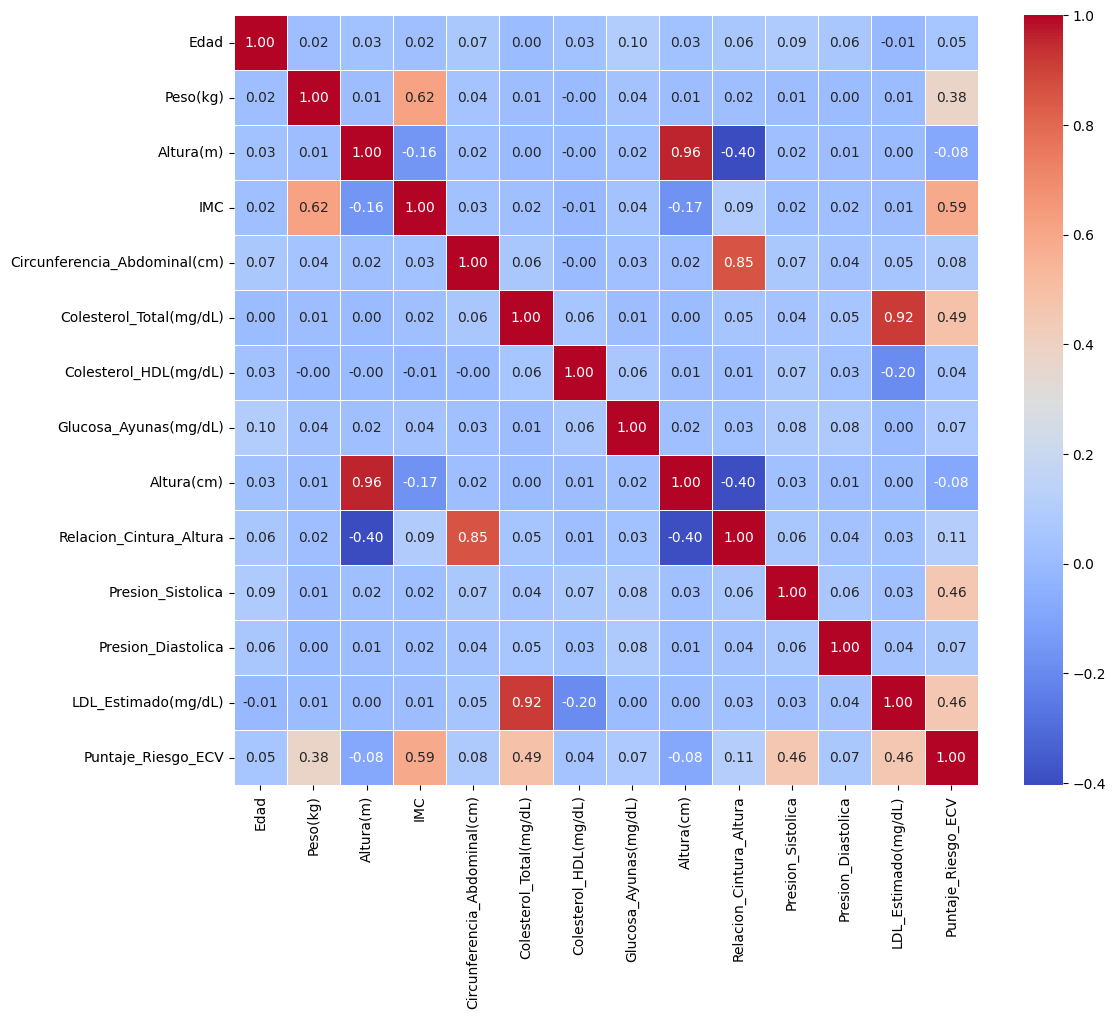

In [83]:
columnas_a_excluir = ['Presion_Arterial(mmHg)']
df1 = df.select_dtypes(include=['float64', 'int64']).drop(columns=columnas_a_excluir, errors='ignore')
plt.figure(figsize=(12, 10))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5);

In [84]:
# eliminamos la columna de puntaje_riesgo_ecv para la variable x
X = df.drop(columns=['Puntaje_Riesgo_ECV', 'Presion_Arterial(mmHg)', 'Nivel_Riesgo_ECV'])
y = df['Puntaje_Riesgo_ECV']
print(X.columns)

Index(['Sexo', 'Edad', 'Peso(kg)', 'Altura(m)', 'IMC',
       'Circunferencia_Abdominal(cm)', 'Colesterol_Total(mg/dL)',
       'Colesterol_HDL(mg/dL)', 'Glucosa_Ayunas(mg/dL)', 'Estado_Tabaquismo',
       'Estado_Diabetes', 'Nivel_Actividad_Fisica',
       'Antecedentes_Familiares_ECV', 'Altura(cm)', 'Relacion_Cintura_Altura',
       'Presion_Sistolica', 'Presion_Diastolica', 'Categoria_Presion_Arterial',
       'LDL_Estimado(mg/dL)'],
      dtype='str')


In [82]:
# Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size=0.75, 
    random_state=123 
)

In [46]:
# Crear el modelo
modelo = DecisionTreeRegressor(random_state=123)

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print(f"Profundidad del árbol: {modelo.get_depth()}") 
print(f"Número de hojas: {modelo.get_n_leaves()}") 

Profundidad del árbol: 18
Número de hojas: 1132


In [47]:
# Error de predicción inicial (RMSE)
pred_inicial = modelo.predict(X_test)
rmse_inicial = mean_squared_error(y_test, pred_inicial)
print(f"RMSE Inicial: {rmse_inicial:.4f}")

RMSE Inicial: 1.3626


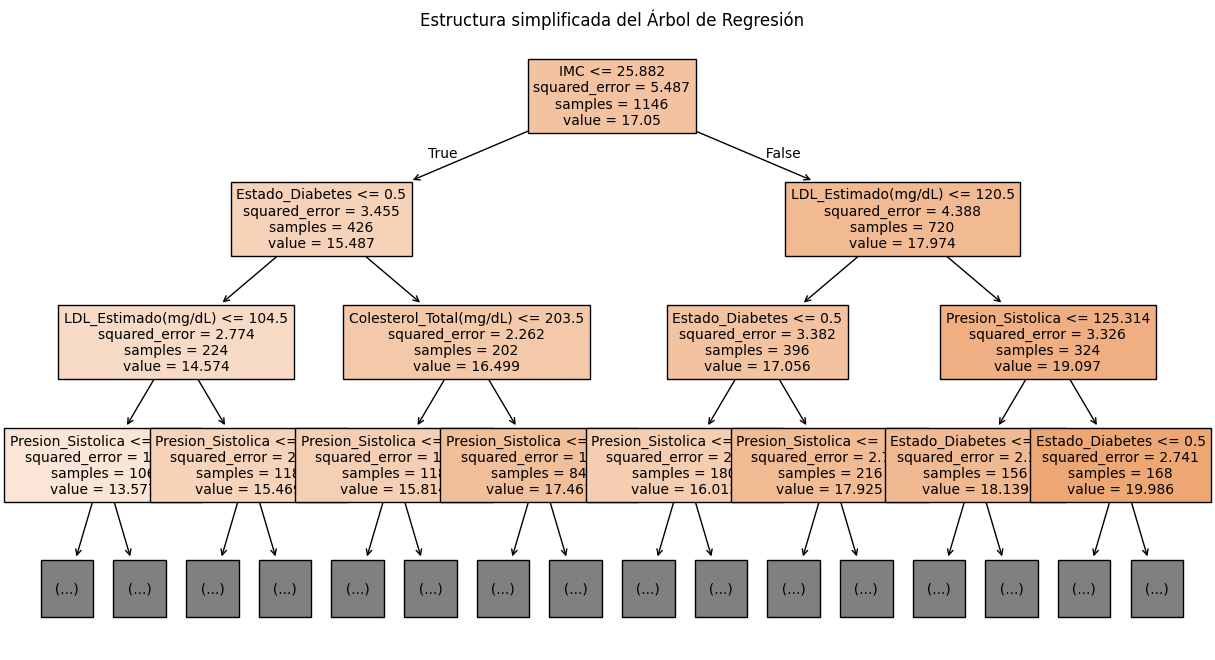

In [59]:
# Visualizar el árbol de decisión 
plt.figure(figsize=(15, 8))
tree.plot_tree(
    decision_tree=modelo, 
    max_depth=3, 
    feature_names=X.columns, 
    filled=True, 
    fontsize=10
)
plt.title("Estructura simplificada del Árbol de Regresión")
plt.show()

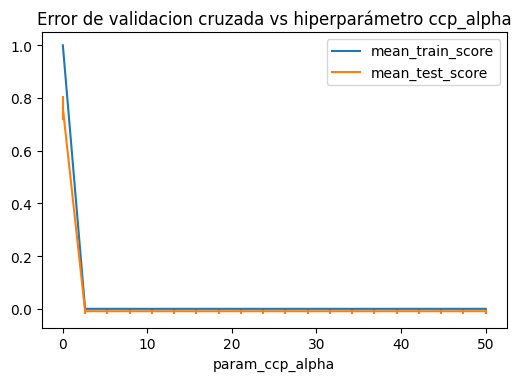

In [76]:
# Definir valores de ccp_alpha a evaluar 
param_grid = {'ccp_alpha': np.linspace(0, 50, 20)}

# Búsqueda del mejor hiperparámetro con Validación Cruzada 
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=123),
    param_grid=param_grid,
    cv=10,
    refit=True,
    return_train_score = True
)
grid.fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(6, 3.84)) 
scores = pd.DataFrame(grid.cv_results_) 
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax) 
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax) 
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha"); 
plt.show()



In [65]:
# Mejor modelo tras la poda 
modelo_final = grid.best_estimator_
grid.best_params_.items()

dict_items([('ccp_alpha', np.float64(0.0))])

In [66]:
# Importancia de los predictores 
importancia = pd.DataFrame({
    'Predictor': X.columns,
    'Importancia': modelo_final.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Importancia de las variables en el riesgo cardiovascular:")
print(importancia)

Importancia de las variables en el riesgo cardiovascular:
                       Predictor  Importancia
4                            IMC     0.355544
15             Presion_Sistolica     0.186656
18           LDL_Estimado(mg/dL)     0.176538
10               Estado_Diabetes     0.161766
6        Colesterol_Total(mg/dL)     0.058432
7          Colesterol_HDL(mg/dL)     0.008018
2                       Peso(kg)     0.007883
1                           Edad     0.007848
3                      Altura(m)     0.006821
5   Circunferencia_Abdominal(cm)     0.006472
14       Relacion_Cintura_Altura     0.006083
16            Presion_Diastolica     0.004765
8          Glucosa_Ayunas(mg/dL)     0.004707
13                    Altura(cm)     0.003845
12   Antecedentes_Familiares_ECV     0.002059
17    Categoria_Presion_Arterial     0.000919
11        Nivel_Actividad_Fisica     0.000569
19              Nivel_Riesgo_ECV     0.000531
9              Estado_Tabaquismo     0.000350
0                     

In [67]:
# Error del modelo final
from sklearn.metrics import root_mean_squared_error


pred_final = modelo_final.predict(X_test)
rmse_final = root_mean_squared_error(y_test, pred_final)

print(f"RMSE Modelo Original: {rmse_inicial:.4f}")
print(f"RMSE Modelo Podado:   {rmse_final:.4f}")

RMSE Modelo Original: 1.3626
RMSE Modelo Podado:   1.1673


In [68]:
# Definir las particiones para validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=0)
train_rmses = []
val_rmses = []

for train_idx, val_idx in kf.split(X_train):
    xtr, xvl = X_train.iloc[train_idx], X_train.iloc[val_idx]
    ytr, yvl = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Entrenar árbol al máximo
    arbol = DecisionTreeRegressor(random_state=123)
    arbol.fit(xtr, ytr)
    
    # Calcular RMSE
    train_rmses.append(np.sqrt(mean_squared_error(ytr, arbol.predict(xtr))))
    val_rmses.append(np.sqrt(mean_squared_error(yvl, arbol.predict(xvl))))

print(f"RMSE promedio entrenamiento: {np.mean(train_rmses):.4f}") 
print(f"RMSE promedio validación: {np.mean(val_rmses):.4f}") 

RMSE promedio entrenamiento: 0.0000
RMSE promedio validación: 1.1913


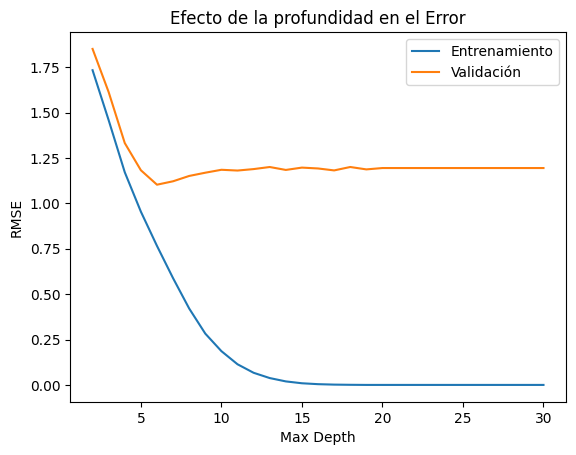

In [ ]:
MAX_DEPTHS = np.arange(2, 31)
MEAN_TRAIN_RMSES = []
MEAN_VAL_RMSES = []

for max_depth in MAX_DEPTHS:
    train_rmses = []
    val_rmses = []
    for train_idx, val_idx in kf.split(X_train):
        xtr, xvl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yvl = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        arbol = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
        arbol.fit(xtr, ytr)
        
        train_rmses.append(np.sqrt(mean_squared_error(ytr, arbol.predict(xtr))))
        val_rmses.append(np.sqrt(mean_squared_error(yvl, arbol.predict(xvl))))
    
    MEAN_TRAIN_RMSES.append(np.mean(train_rmses))
    MEAN_VAL_RMSES.append(np.mean(val_rmses))

# Graficar resultados 
plt.plot(MAX_DEPTHS, MEAN_TRAIN_RMSES, label='Entrenamiento') 
plt.plot(MAX_DEPTHS, MEAN_VAL_RMSES, label='Validación') 
plt.xlabel('Max Depth') 
plt.ylabel('RMSE') 
plt.legend() 
plt.show()

In [70]:

arbol_final = DecisionTreeRegressor(
    max_depth=6,          
    min_samples_leaf=27,   
    random_state=123
)

arbol_final.fit(X_train, y_train) 

# Calcular nuevo desempeño 
train_rmse_f = np.sqrt(mean_squared_error(y_train, arbol_final.predict(X_train))) 
test_rmse_f = np.sqrt(mean_squared_error(y_test, arbol_final.predict(X_test))) 

print(f'Nuevo RMSE entrenamiento: {train_rmse_f:.4f}') 
print(f'Nuevo RMSE test: {test_rmse_f:.4f}') 

Nuevo RMSE entrenamiento: 0.9640
Nuevo RMSE test: 1.2000


In [71]:
print(f'Profundidad del árbol: {arbol.get_depth()}') 
print(f'Número de hojas del árbol: {arbol.get_n_leaves()}') 
print(f'Parámetros usados en el entrenamiento: {arbol.get_params()}') 

Profundidad del árbol: 19
Número de hojas del árbol: 901
Parámetros usados en el entrenamiento: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': np.int64(30), 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


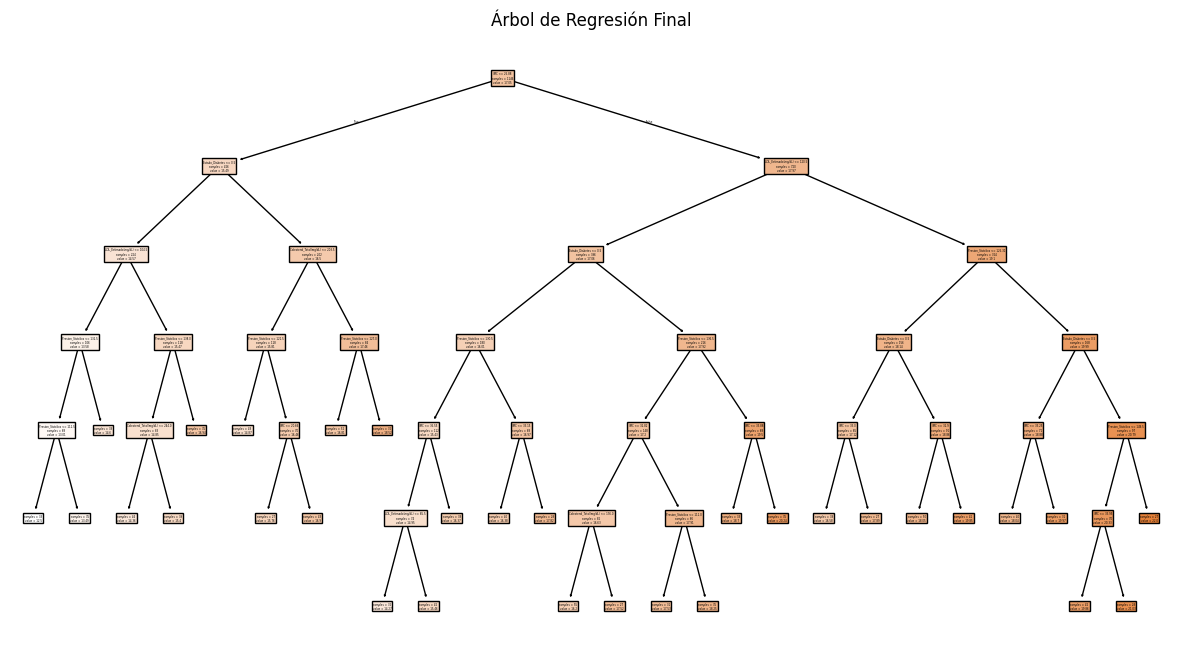

In [72]:
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(
    arbol_final,
    feature_names=X.columns,
    filled=True,
    impurity=False,
    ax=ax,
    precision=2
) 
plt.title("Árbol de Regresión Final")
plt.show()